In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
walmart_sales = pd.read_csv("walmart_sales.csv")

walmart_sales.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
print(walmart_sales.info())
print(walmart_sales.describe())
print(walmart_sales.isna().any()) # no NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB
None
             Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000

In [4]:
walmart_sales["Date"] = pd.to_datetime(walmart_sales["Date"], format = "%d-%m-%Y")
print(walmart_sales["Date"].min())
print(walmart_sales["Date"].max())

2010-02-05 00:00:00
2012-10-26 00:00:00


In [ ]:
# Dataset cover a period of almost 3 years, from February 5 2010 to October 26 2012

In [5]:
walmart_sales["Store"].value_counts()

Store
1     143
24    143
26    143
27    143
28    143
29    143
30    143
31    143
32    143
33    143
34    143
35    143
36    143
37    143
38    143
39    143
40    143
41    143
42    143
43    143
44    143
25    143
23    143
2     143
22    143
3     143
4     143
5     143
6     143
7     143
8     143
9     143
10    143
11    143
12    143
13    143
14    143
15    143
16    143
17    143
18    143
19    143
20    143
21    143
45    143
Name: count, dtype: int64

In [ ]:
# Every store has a count of 143 observations

In [64]:
store_sales_percentage = walmart_sales.groupby("Store")["Weekly_Sales"].sum()/ walmart_sales["Weekly_Sales"].sum() * 100

store_sales_percentage.sort_values(ascending = False) 

Store
20    4.473623
4     4.446107
14    4.289602
13    4.252759
2     4.087479
10    4.031600
27    3.767963
6     3.321194
1     3.301107
39    3.079098
19    3.067065
31    2.962853
23    2.950039
24    2.879764
11    2.878974
28    2.809226
41    2.691644
32    2.476085
18    2.302356
22    2.183032
12    2.141644
26    2.128718
34    2.052030
40    2.046398
35    1.952151
8     1.928855
17    1.896660
45    1.668275
21    1.604785
25    1.500043
43    1.344255
15    1.323004
7     1.211157
42    1.180988
9     1.154619
29    1.145006
16    1.102123
37    1.101385
30    0.930902
3     0.854755
38    0.818730
36    0.792793
5     0.674992
44    0.642596
33    0.551566
Name: Weekly_Sales, dtype: float64

In [ ]:
# Store 20 has the largest percentage of total sales per week (4.47%) while store 33 has the lowest (0.55%)

In [7]:
walmart_sales.corr()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Store,1.000000e+00,1.577347e-13,-0.335332,-4.735625e-16,-0.022659,0.060023,-0.209492,0.223531
Date,1.577347e-13,1.000000e+00,0.006949,-1.328524e-02,0.145357,0.771444,0.077157,-0.248203
Weekly_Sales,-3.353320e-01,6.949360e-03,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176
Holiday_Flag,-4.735625e-16,-1.328524e-02,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960
Temperature,-2.265908e-02,1.453566e-01,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158
Fuel_Price,6.002295e-02,7.714439e-01,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684
CPI,-2.094919e-01,7.715746e-02,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020
Unemployment,2.235313e-01,-2.482029e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000


In [ ]:
# There aren't significant correlation between weekly sales and variables of interest such as Temperature (0.06 correlation) or Fuel Price (0.009 correlation)
# The strongest correlation is between weekly sales and the unemployment rate, but even here there is only a very weak correlation (-0.1). 
# That may indicate that sales could be driven by other causes, such as the dimension of the store or its geograpichal position 

In [9]:
store_means = walmart_sales.groupby("Store")[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'Unemployment']].mean()

store_means_sorted = store_means.sort_values(by="Weekly_Sales", ascending=False)

best = store_means_sorted.head(3)
worst = store_means_sorted.tail(3)

print(best[["Temperature", "Fuel_Price", "Unemployment"]].mean())
print(worst[["Temperature", "Fuel_Price", "Unemployment"]].mean())

Temperature     58.498578
Fuel_Price       3.350730
Unemployment     7.328284
dtype: float64
Temperature     66.611818
Fuel_Price       3.360590
Unemployment     7.188061
dtype: float64


In [ ]:
# The lack of correlation is demostrated by the mean of values of the top 3 best and worst Walmart stores, which is very similar between them
## The only significant difference is with Temperature mean. Top 3 stores have a mean Temperature of 58°F (14°C) while last 3 stores have a mean Temperature of 66°F (19°C)
### It is improbable that a difference in temperature of 8°F (5°C) could define better or worse sales per week

In [61]:
holiday_sales = walmart_sales[walmart_sales["Holiday_Flag"] == 1]
print(holiday_sales["Weekly_Sales"].mean())

not_holiday = walmart_sales[walmart_sales["Holiday_Flag"] == 0]
print(not_holiday["Weekly_Sales"].mean())

difference = (holiday_sales["Weekly_Sales"].mean() - not_holiday["Weekly_Sales"].mean()) / holiday_sales["Weekly_Sales"].mean() * 100 

difference

1122887.8923555557
1041256.3802088555


np.float64(7.269782914432926)

In [ ]:
# In general, during holiday days sales are higher by 7%

Date
2010-02-05    1.105572e+06
2010-02-12    1.074148e+06
2010-02-19    1.072822e+06
2010-02-26    9.770794e+05
2010-03-05    1.041588e+06
                  ...     
2012-09-28    9.718867e+05
2012-10-05    1.057036e+06
2012-10-12    1.025078e+06
2012-10-19    1.002720e+06
2012-10-26    1.012091e+06
Name: Weekly_Sales, Length: 143, dtype: float64


<Axes: xlabel='Date'>

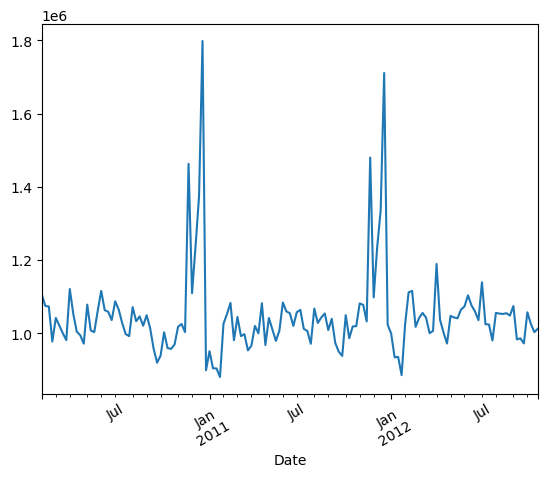

In [13]:
weekly_trend = walmart_sales.groupby("Date")["Weekly_Sales"].mean().sort_index(ascending = True)
print(weekly_trend)

weekly_trend.plot(x = "Date",
                  y = "Sales",
                  kind = "line", 
                  rot = 30)

In [14]:
# Sales tend to increase between November and December, probably because of holidays like Thanksgiving, Christmas and New Year
## Also, sales seem to decrease during January and February and then stabilize again
### It may be better to invest more on advertisement during winter season 

<Axes: >

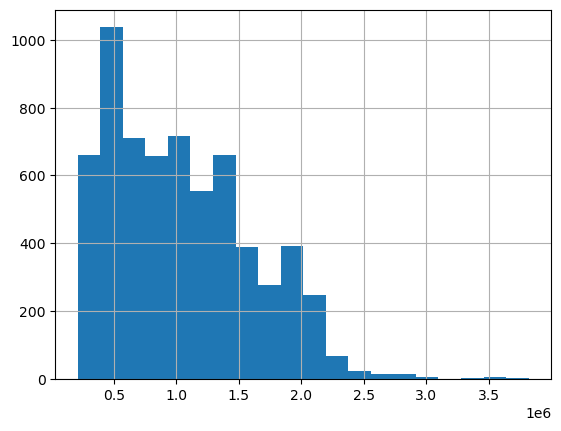

In [50]:
walmart_sales["Weekly_Sales"].hist(bins = 20)

In [62]:
# Weekly sales are not normally distributed with a right tail that represents a small number of observations that register more than 1.5 million
## Most of sales observations are between $200.000 and 1.5 $1.5 million, with the highest peak of more of 1000 observations with $500 thousand in sales per week